# Machine Learning Classifiers



In this project a few additional classifiers are trained and tested, 3 supervised and 3 unsupervised(clustering) the prject includes preprocessing, training, testing, evaluations, hyperparameter tuning, PCA, clustering and evaluation metrics for unsupervised learning

# Supervised Machine Learning Classifiers

In [1]:
!pip install shap
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
import xgboost as xgb
from xgboost import plot_importance
import shap

# Load the Breast Cancer dataset
data = load_breast_cancer()

## Exploratory Data Analysis


In [2]:
import pandas as pd
df=pd.DataFrame(data.data,columns=data.feature_names)
df['target']=data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# the label is target
# drop or rows that are missing target
df.dropna(subset=['target'], inplace=True)

In [4]:
X = df.iloc[:, :-1]  #split label from parameters
y = df.iloc[:, -1]

In [5]:
feature_names = X.columns
label_name = y.name

print("Feature names:", feature_names)
print("Label column:", label_name)

Feature names: Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')
Label column: target


In [6]:
# Important information for our data
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [7]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 569 entries, 0 to 568
Series name: target
Non-Null Count  Dtype
--------------  -----
569 non-null    int64
dtypes: int64(1)
memory usage: 4.6 KB


We observe that our dataset consists of 569 rows and 29 different features. There are no missing values in any of the measurements, and none of the features are categorical.

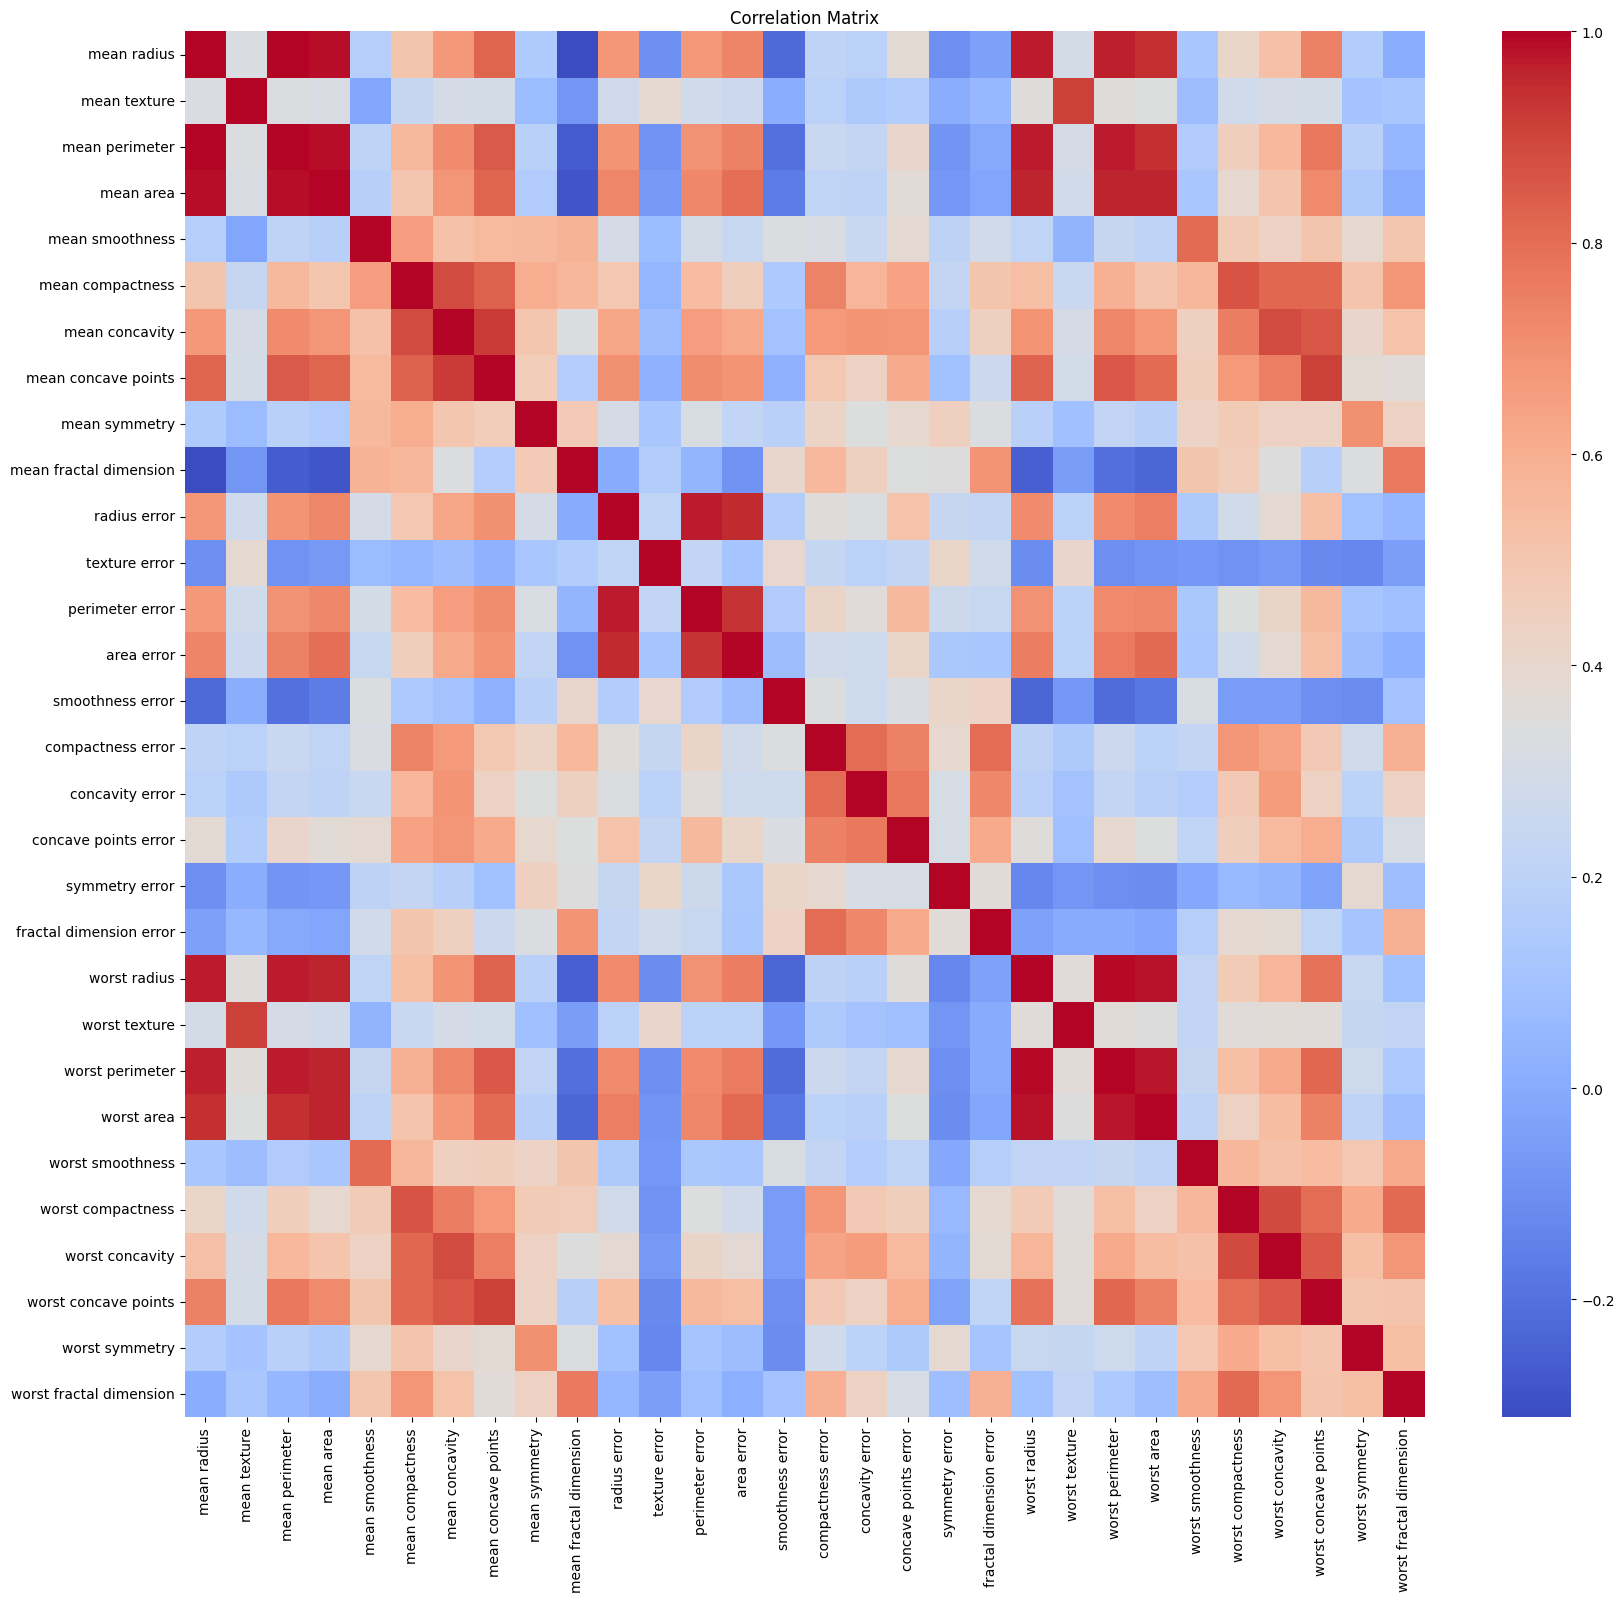

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
correlation_matrix = df.drop('target', axis=1).corr()

# Visualization
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

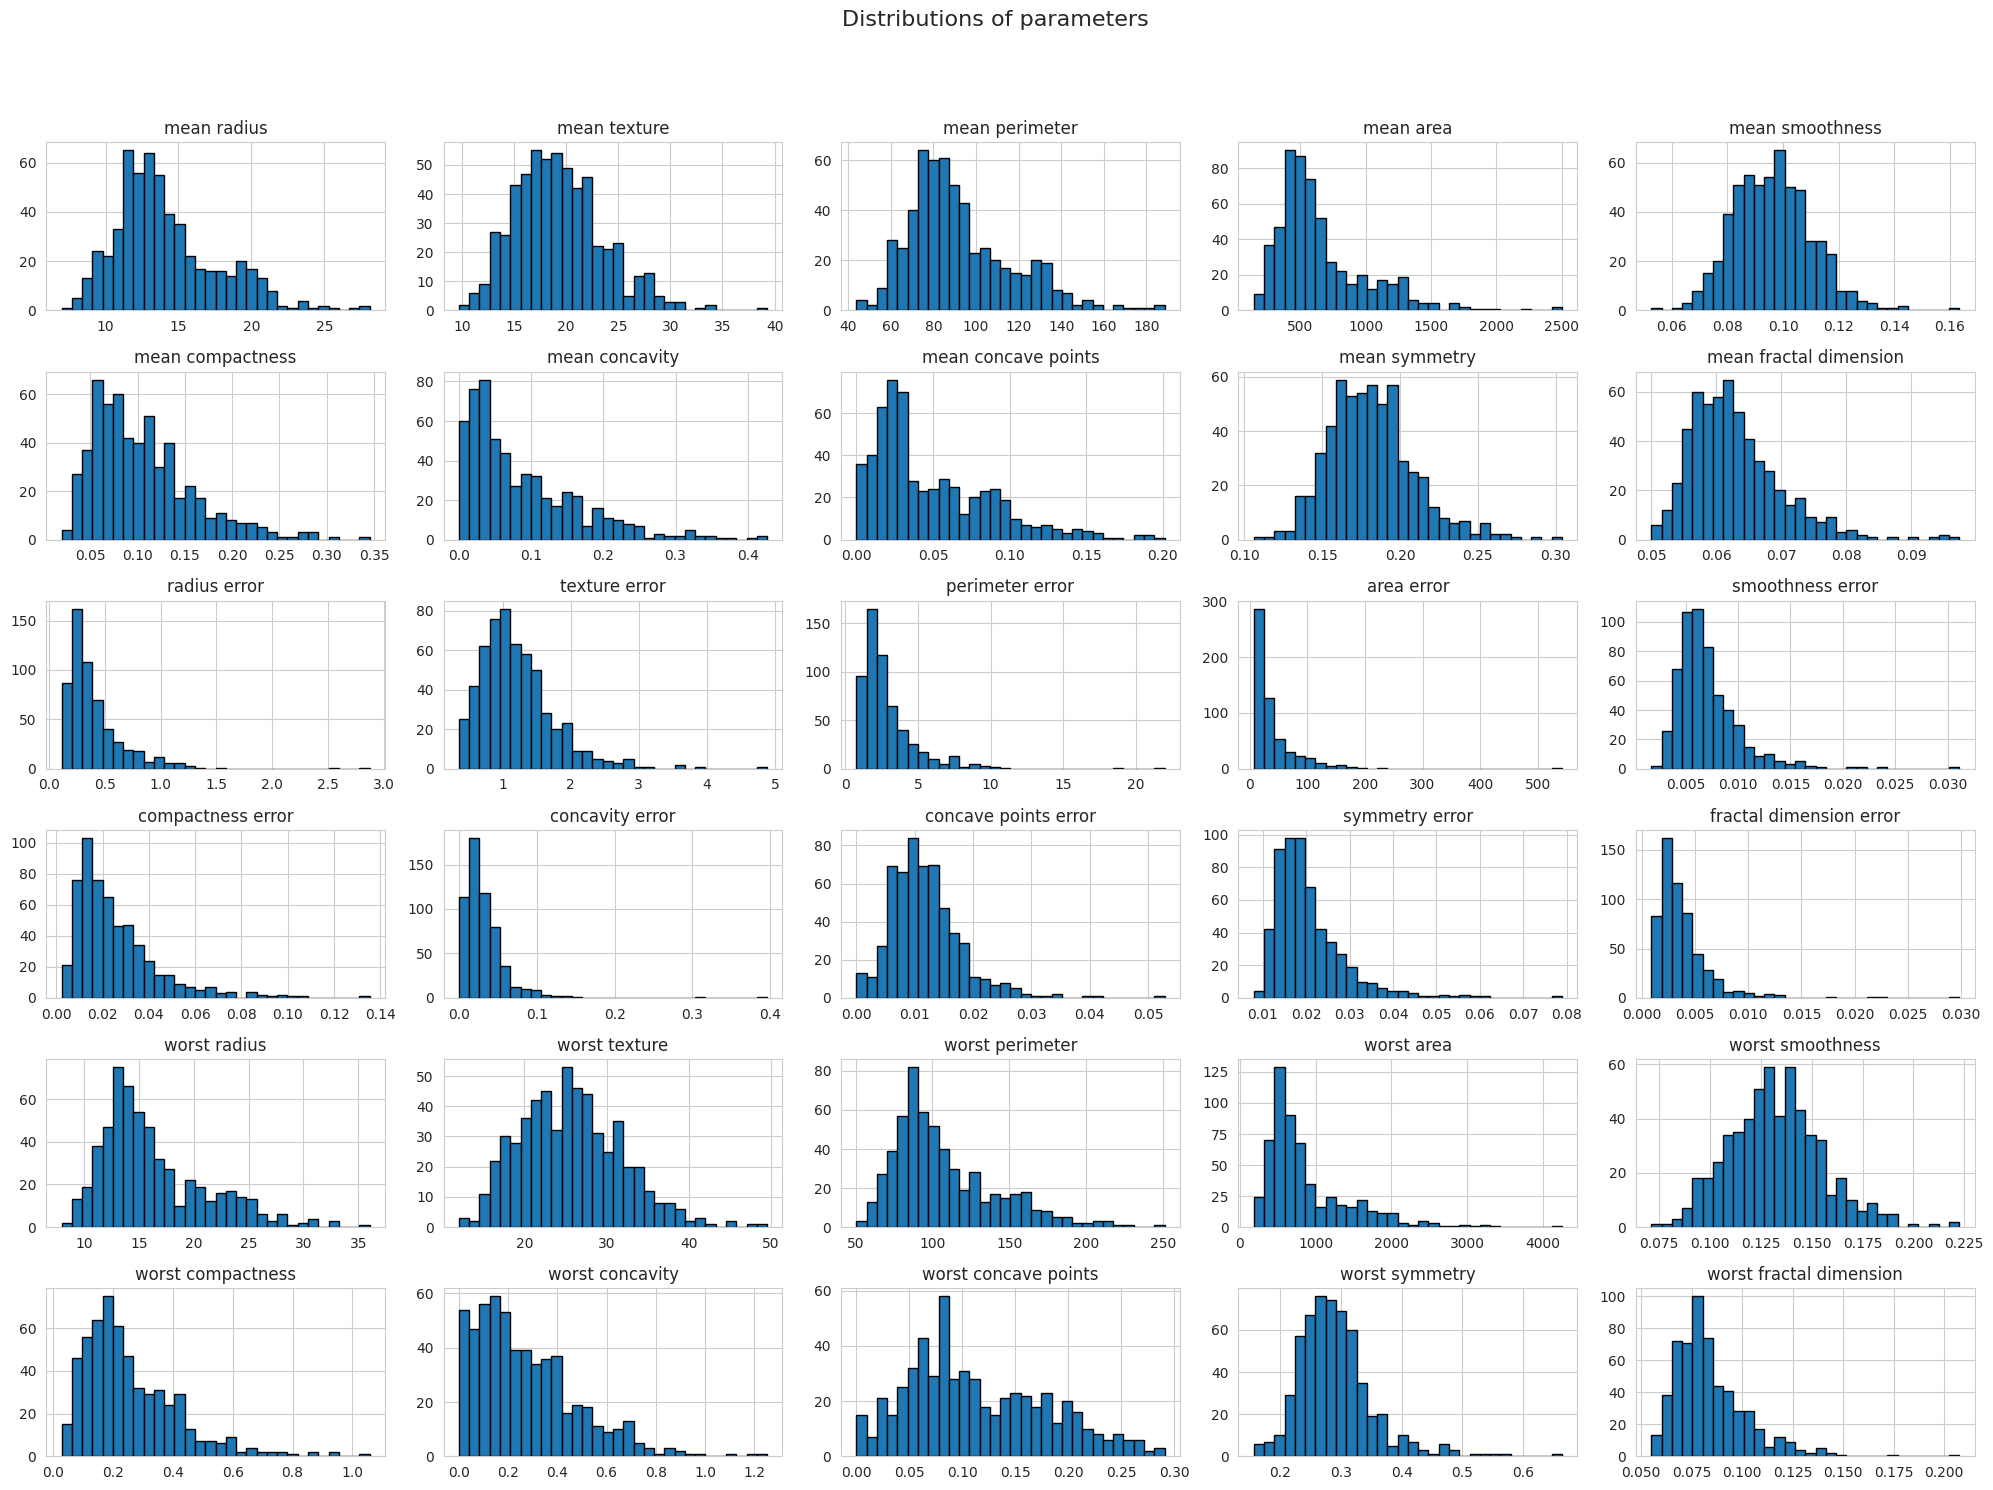

In [9]:

# scatter plots
features_df = df.drop('target', axis=1)
sns.set_style("whitegrid")

# Plot
features_df.hist(figsize=(20, 15), bins=30, edgecolor='black')
plt.suptitle('Distributions of parameters', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

## Preprocessing

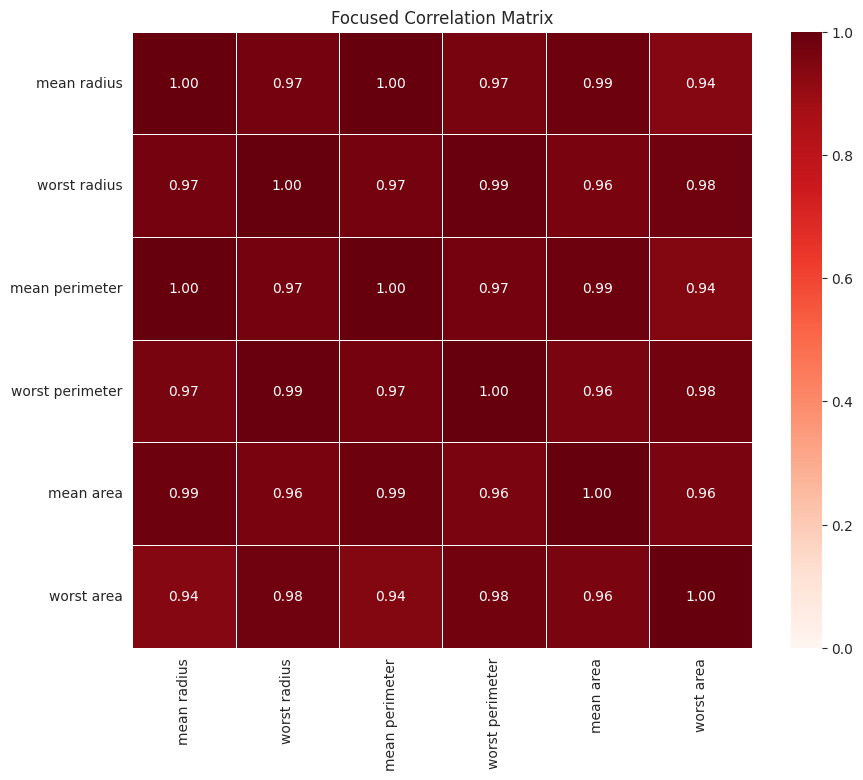

In [10]:

# Let's start with some obvious correlated parameters
selected_features = [
    'mean radius',
    'worst radius',
    'mean perimeter',
    'worst perimeter',
    'mean area',
    'worst area'
]

selected_df = df[selected_features]
# Focused correlation matrix
correlation_matrix_selected = selected_df.corr()

# Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_selected, annot=True, cmap='Reds', fmt=".2f", linewidths=.5,
            vmin=0, vmax=1)
plt.title('Focused Correlation Matrix')
plt.show()

In [11]:
#We drop everything except from worst radius
features_to_drop = [
    'mean radius',
    'mean perimeter',
    'mean area',
    'worst perimeter',
    'worst area'
]

df_processed = df.drop(columns=features_to_drop)

X = df_processed.drop('target', axis=1)
y = df_processed['target']

In [12]:
# We are going to drop errors as well since we can't expect the randomness of those errors to be a good predictor.
error_features = [col for col in X.columns if 'error' in col]

if error_features:
    print(f"Collumns containing errors): {error_features}")
    # Τα πετάμε
    X = X.drop(columns=error_features)

print(f"\n Number of collumns: {X.shape[1]}")
print("Number of collumns left")
print(X.columns.tolist())

Collumns containing errors): ['radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error']

 Number of collumns: 15
Number of collumns left
['mean texture', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'worst radius', 'worst texture', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']


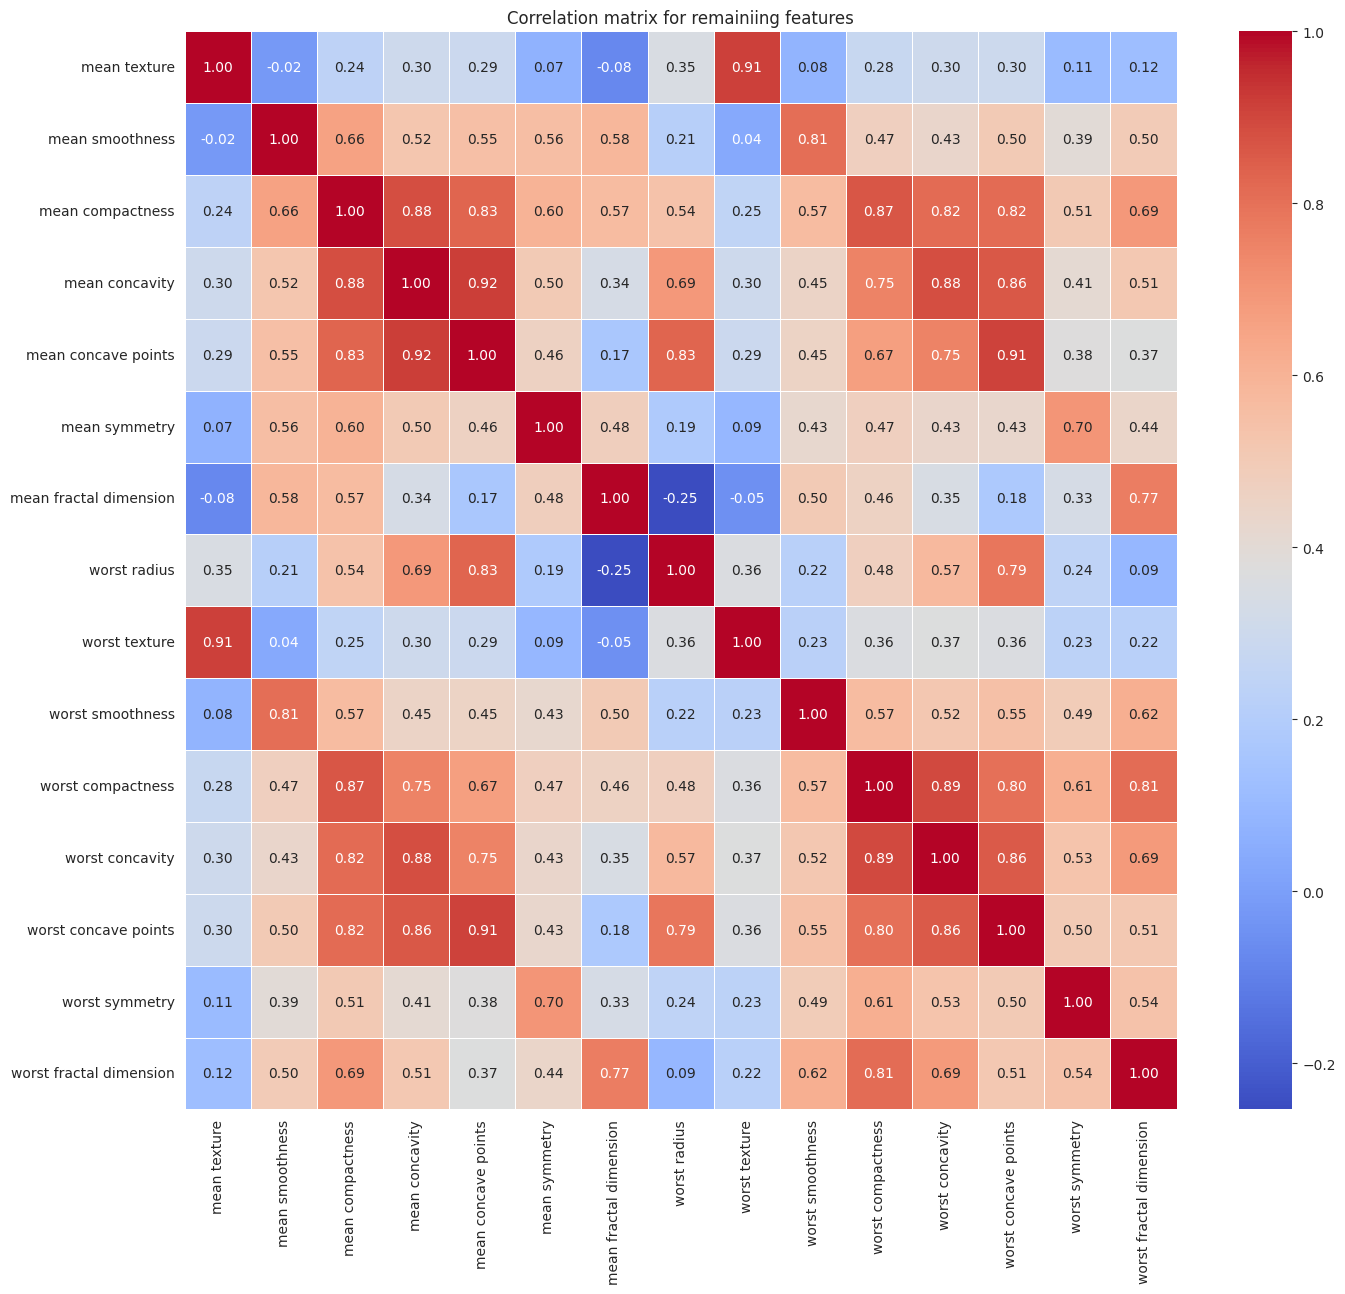

In [13]:

#Correlation matrix for the remaining features
correlation_matrix_processed = X.corr()

# Visualization
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix_processed, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation matrix for remainiing features')
plt.show()

I will continue by removing any feature that has a correlation greater than 80% with another.

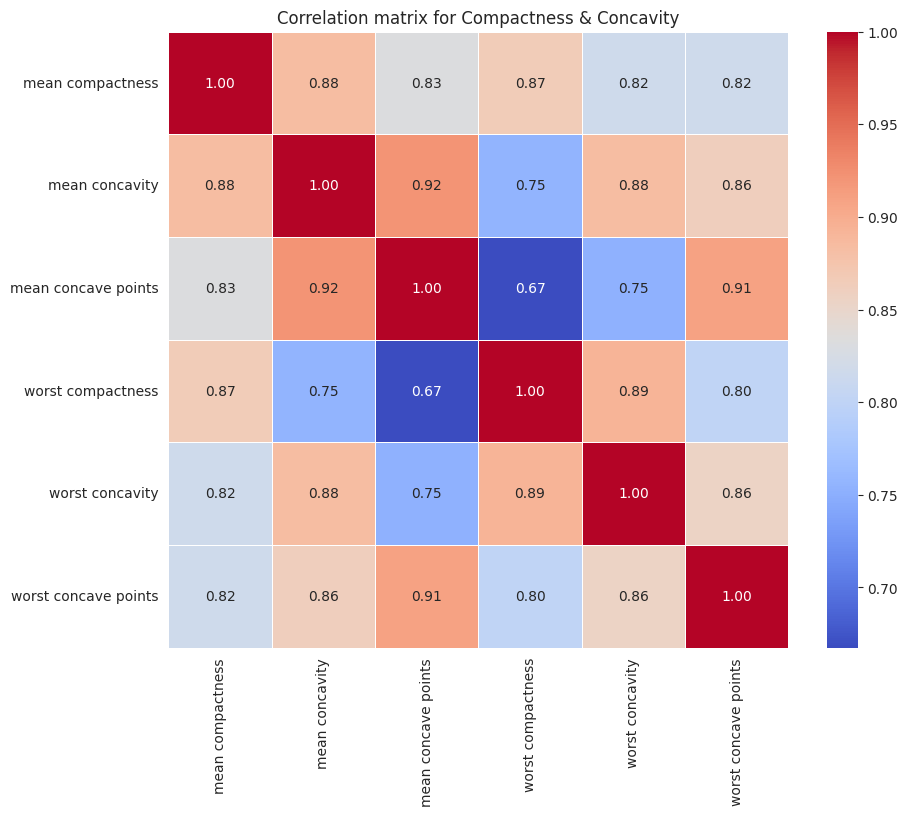

In [14]:

# We repeat the process for another group of closely correlated features
subset_features_compactness_concavity = [
    'mean compactness',
    'mean concavity',
    'mean concave points',
    'worst compactness',
    'worst concavity',
    'worst concave points'
]

present_subset_features_cc = [f for f in subset_features_compactness_concavity if f in X.columns]

X_subset_cc = X[present_subset_features_cc]

# New correlation matrix
correlation_matrix_subset_cc = X_subset_cc.corr()

# Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_subset_cc, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation matrix for Compactness & Concavity')
plt.show()

In [15]:
# I will only keep mean compactness
features_to_drop_cc = [
    'mean concavity',
    'mean concave points',
    'worst compactness',
    'worst concavity',
    'worst concave points'
]

actual_features_to_drop_cc = [f for f in features_to_drop_cc if f in X.columns]

if actual_features_to_drop_cc:
    print(f"Features to be removed: {actual_features_to_drop_cc}")
    X = X.drop(columns=actual_features_to_drop_cc)


print(f"\nNew number of remaining features: {X.shape[1]}")
print("Remaining features")
print(X.columns.tolist())


Features to be removed: ['mean concavity', 'mean concave points', 'worst compactness', 'worst concavity', 'worst concave points']

New number of remaining features: 10
Remaining features
['mean texture', 'mean smoothness', 'mean compactness', 'mean symmetry', 'mean fractal dimension', 'worst radius', 'worst texture', 'worst smoothness', 'worst symmetry', 'worst fractal dimension']


In [16]:
# I also drop mean texture and mean smoothness due to large correlation
#(>80%) with their "worst" counterparts.
features_to_drop_mean = [
    'mean smoothness',
    'mean texture'
]

actual_features_to_drop_mean = [f for f in features_to_drop_mean if f in X.columns]

if actual_features_to_drop_mean:
    print(f"We drop: {actual_features_to_drop_mean}")
    X = X.drop(columns=actual_features_to_drop_mean)

print(f"\nNew number of characteristics: {X.shape[1]}")
print("Remaining features:")
print(X.columns.tolist())


We drop: ['mean smoothness', 'mean texture']

New number of characteristics: 8
Remaining features:
['mean compactness', 'mean symmetry', 'mean fractal dimension', 'worst radius', 'worst texture', 'worst smoothness', 'worst symmetry', 'worst fractal dimension']


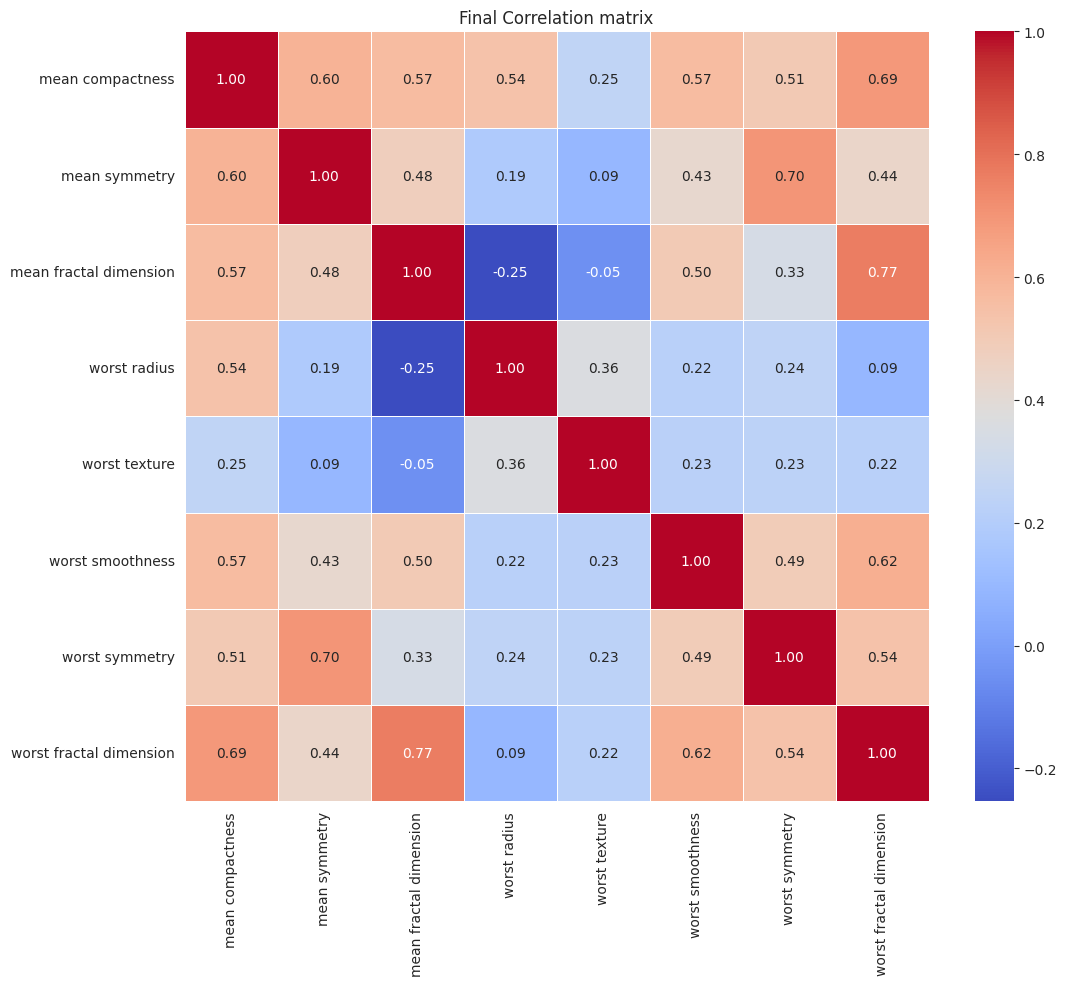

In [17]:

# New correlation matrix
correlation_matrix_survived = X.corr()

# Visualization
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_survived, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Final Correlation matrix')
plt.show()

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

# Feature Selection
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

# The features pipeline: Scaling
numerical_pipeline = Pipeline([
    ('scaler', StandardScaler()),
])

# Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features)
    ],
)
# Apply the transformation
Xr = preprocessor.fit_transform(X)
yr = y

We split the dataset to prepare for training.



In [19]:
from sklearn.model_selection import train_test_split

# random_state 42 for repeatability.
X_train, X_test, y_train, y_test = train_test_split(Xr, yr, test_size=0.3, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (398, 8)
X_test: (171, 8)
y_train: (398,)
y_test: (171,)


## Training and Hyperparameter Tuning

We are going to use the following classifiers

-  AdaBoost Model
-  Gradient Boosting Model
-  XGBoost Model



In [20]:
from sklearn.metrics import f1_score, precision_score, recall_score, make_scorer
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
#To be used in evaluation
scoring = {
    'f1': make_scorer(f1_score, pos_label=1),
    'precision': make_scorer(precision_score, pos_label=1),
    'recall': make_scorer(recall_score, pos_label=1)
}

# Weights for y_train
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Dictionary
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

# Weigths for y_train samples
sample_weights = np.array([class_weight_dict[label] for label in y_train])

In [21]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer
import pandas as pd


ada_model = AdaBoostClassifier(random_state=42)

# Hyperparameters
param_grid_ada = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.5, 1.0, 2.0]
}

# GridSearchCV with 5-fold cross-validation
grid_search_ada = GridSearchCV(
    estimator=ada_model,
    param_grid=param_grid_ada,
    scoring=scoring,
    cv=5,
    n_jobs=-1,
    refit='f1'
)

# Training
grid_search_ada.fit(X_train, y_train, sample_weight=sample_weights)

# Evaluation
print(f"\nThe F1 Score for AdaBoost: {grid_search_ada.best_score_:.4f}")
print(f"Best parameters: {grid_search_ada.best_params_}")

# All scores
results_ada = pd.DataFrame(grid_search_ada.cv_results_)
display(results_ada[['param_n_estimators', 'param_learning_rate', 'mean_test_f1', 'std_test_f1', 'mean_test_precision', 'mean_test_recall']])

# Save best model
best_ada_model = grid_search_ada.best_estimator_



The F1 Score for AdaBoost: 0.9644
Best parameters: {'learning_rate': 0.1, 'n_estimators': 100}


,param_n_estimators,param_learning_rate,mean_test_f1,std_test_f1,mean_test_precision,mean_test_recall
0,50,0.01,0.914646,0.024359,0.904044,0.927755
1,100,0.01,0.914646,0.024359,0.904044,0.927755
2,200,0.01,0.927261,0.013094,0.912417,0.943755
3,300,0.01,0.938780,0.009884,0.923459,0.955837
4,50,0.10,0.956271,0.013736,0.945373,0.967837
5,100,0.10,0.964355,0.013315,0.953312,0.975918
6,200,0.10,0.962098,0.014618,0.956691,0.967918
7,300,0.10,0.959999,0.016734,0.956389,0.963837
8,50,0.50,0.960077,0.016828,0.952697,0.967837
9,100,0.50,0.960277,0.021801,0.949161,0.971837


In [22]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer
import pandas as pd



# The model (Gradient Boosting Classifier)
gb_model = GradientBoostingClassifier(random_state=42)

# Hyperparameters for Gradient Boosting Model
param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.1, 0.5, 1.0],
    'max_depth': [3, 5],
    'subsample': [0.7, 0.9]
}

# GridSearchCV with 5-fold cross-validation
grid_search_gb = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid_gb,
    scoring=scoring,
    cv=5,
    n_jobs=-1,
    refit='f1'
)

# Training
grid_search_gb.fit(X_train, y_train, sample_weight=sample_weights)

# Results
print(f"\nThe best F1 Score for Gradient Boosting: {grid_search_gb.best_score_:.4f}")
print(f"Best hyperparameters: {grid_search_gb.best_params_}")

# All scores
results_gb = pd.DataFrame(grid_search_gb.cv_results_)
display(results_gb[['param_n_estimators', 'param_learning_rate', 'param_max_depth', 'param_subsample', 'mean_test_f1', 'std_test_f1', 'mean_test_precision', 'mean_test_recall']]) # Updated displayed columns

# Save the best model
best_gb_model = grid_search_gb.best_estimator_



The best F1 Score for Gradient Boosting: 0.9701
Best hyperparameters: {'learning_rate': 1.0, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.9}


,param_n_estimators,param_learning_rate,param_max_depth,param_subsample,mean_test_f1,std_test_f1,mean_test_precision,mean_test_recall
0,50,0.1,3,0.7,0.962489,0.019254,0.945844,0.979837
1,50,0.1,3,0.9,0.956392,0.018590,0.941614,0.971837
2,100,0.1,3,0.7,0.966491,0.017121,0.949846,0.983918
3,100,0.1,3,0.9,0.968236,0.019374,0.957231,0.979918
4,200,0.1,3,0.7,0.966491,0.017121,0.949846,0.983918
5,200,0.1,3,0.9,0.966256,0.017472,0.953231,0.979918
6,50,0.1,5,0.7,0.962491,0.019247,0.945916,0.979918
7,50,0.1,5,0.9,0.948301,0.023108,0.937909,0.959918
8,100,0.1,5,0.7,0.966491,0.017121,0.949846,0.983918
9,100,0.1,5,0.9,0.954291,0.018657,0.941451,0.967837


In [23]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer
import pandas as pd

# The model (XGBoost Classifier)
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Hyperparameters for XGBoost Model
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.1, 0.2, 0.3],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0]
}

# GridSearchCV with 5-fold cross-validation
grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    scoring=scoring,
    cv=5,
    n_jobs=-1,
    refit='f1'
)

# Training
grid_search_xgb.fit(X_train, y_train, sample_weight=sample_weights)

# Results
print(f"\nThe best F1 Score for XGBoost: {grid_search_xgb.best_score_:.4f}")
print(f"Best Hyperparameters: {grid_search_xgb.best_params_}")

# All scores
results_xgb = pd.DataFrame(grid_search_xgb.cv_results_)
display(results_xgb[['param_n_estimators', 'param_learning_rate', 'param_max_depth', 'param_subsample', 'param_colsample_bytree', 'mean_test_f1', 'std_test_f1', 'mean_test_precision', 'mean_test_recall']])

# Save best model
best_xgb_model = grid_search_xgb.best_estimator_



The best F1 Score for XGBoost: 0.9741
Best Hyperparameters: {'colsample_bytree': 0.9, 'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 50, 'subsample': 0.9}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:07:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,param_n_estimators,param_learning_rate,param_max_depth,param_subsample,param_colsample_bytree,mean_test_f1,std_test_f1,mean_test_precision,mean_test_recall
0,50,0.1,3,0.7,0.7,0.968078,0.016059,0.960543,0.975918
1,50,0.1,3,0.9,0.7,0.970098,0.017955,0.960621,0.979918
2,50,0.1,3,1.0,0.7,0.963913,0.020985,0.956298,0.971755
3,100,0.1,3,0.7,0.7,0.970098,0.017955,0.960621,0.979918
4,100,0.1,3,0.9,0.7,0.968158,0.017292,0.956778,0.979918
...,...,...,...,...,...,...,...,...,...
238,100,0.3,7,0.9,1.0,0.964192,0.024212,0.953002,0.975755
239,100,0.3,7,1.0,1.0,0.968313,0.022911,0.957315,0.979837
240,200,0.3,7,0.7,1.0,0.964195,0.020670,0.953071,0.975837
241,200,0.3,7,0.9,1.0,0.964192,0.024212,0.953002,0.975755


## Evaluation



---



---



/tmp/ipykernel_3868/1316129215.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Score', data=test_scores_df[test_scores_df['Metric'] == metric], ax=axes[i], palette='viridis')
/tmp/ipykernel_3868/1316129215.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Score', data=test_scores_df[test_scores_df['Metric'] == metric], ax=axes[i], palette='viridis')
/tmp/ipykernel_3868/1316129215.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Score', data=test_scores_df[test_scores_df['Metric'] == metri

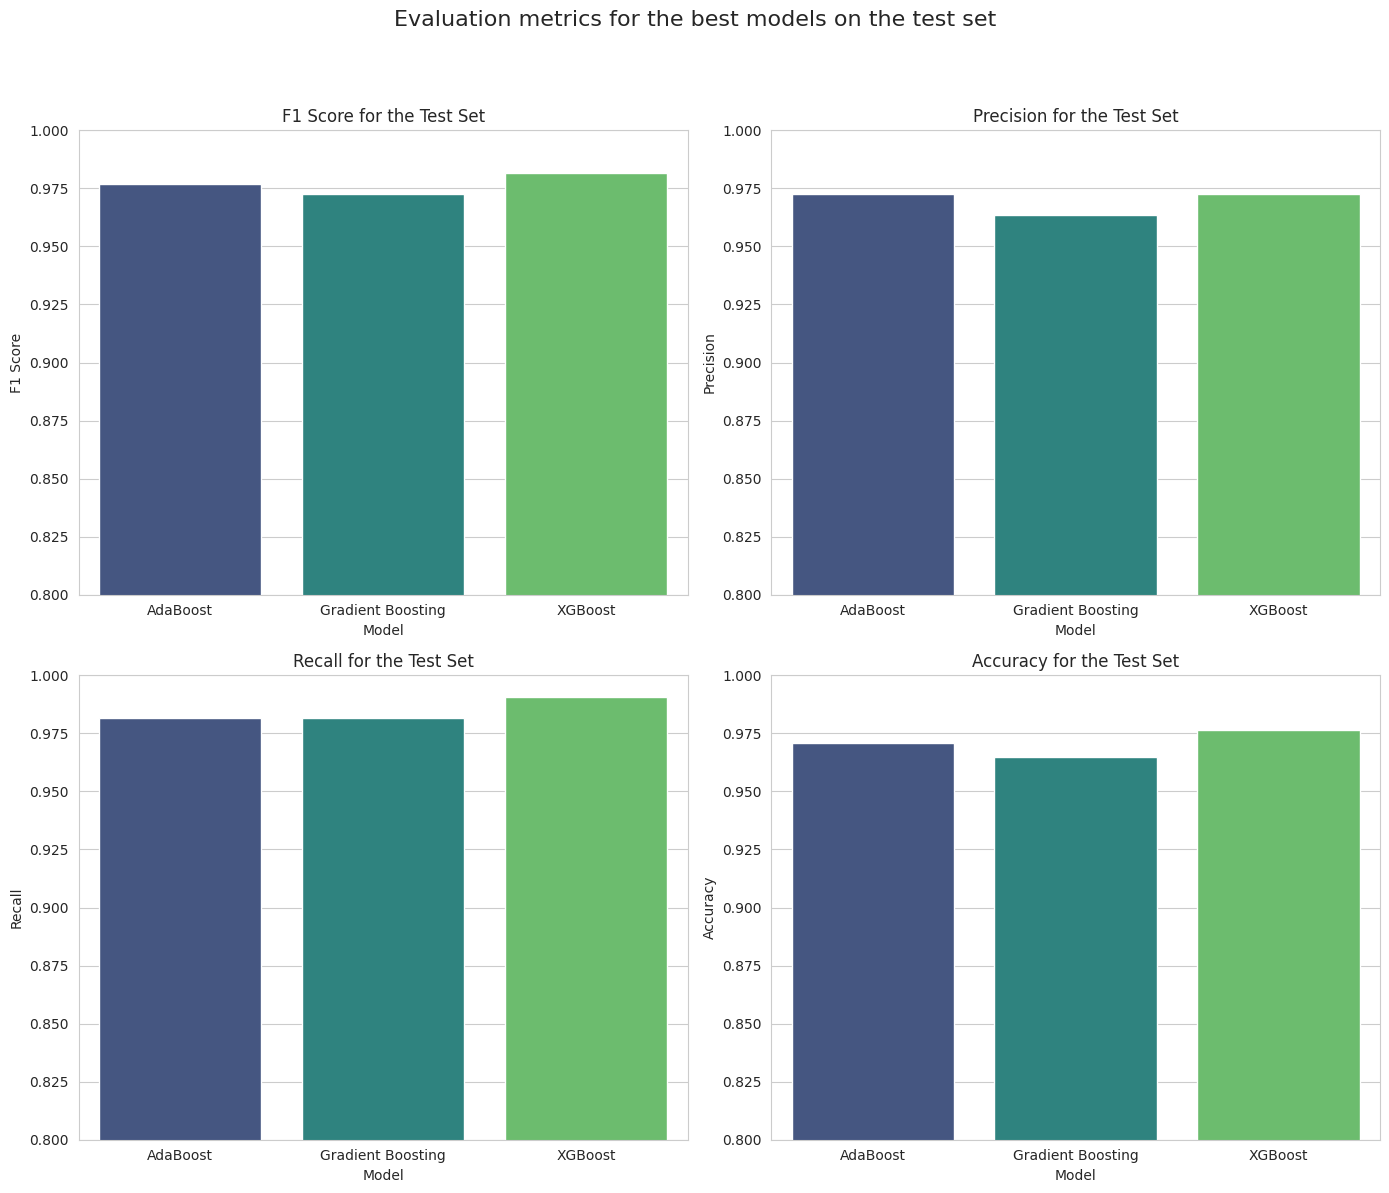

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

test_scores_list = []

# Evaluation of AdaBoost model for the test set
if 'best_ada_model' in locals():
    y_pred_ada = best_ada_model.predict(X_test)
    test_scores_list.append({
        'Model': 'AdaBoost',
        'Metric': 'F1 Score',
        'Score': f1_score(y_test, y_pred_ada)
    })
    test_scores_list.append({
        'Model': 'AdaBoost',
        'Metric': 'Precision',
        'Score': precision_score(y_test, y_pred_ada)
    })
    test_scores_list.append({
        'Model': 'AdaBoost',
        'Metric': 'Recall',
        'Score': recall_score(y_test, y_pred_ada)
    })
    test_scores_list.append({
        'Model': 'AdaBoost',
        'Metric': 'Accuracy',
        'Score': accuracy_score(y_test, y_pred_ada)
    })

# Evaluation Gradient Boost model for the test set
if 'best_gb_model' in locals():
    y_pred_gb = best_gb_model.predict(X_test)
    test_scores_list.append({
        'Model': 'Gradient Boosting',
        'Metric': 'F1 Score',
        'Score': f1_score(y_test, y_pred_gb)
    })
    test_scores_list.append({
        'Model': 'Gradient Boosting',
        'Metric': 'Precision',
        'Score': precision_score(y_test, y_pred_gb)
    })
    test_scores_list.append({
        'Model': 'Gradient Boosting',
        'Metric': 'Recall',
        'Score': recall_score(y_test, y_pred_gb)
    })
    test_scores_list.append({
        'Model': 'Gradient Boosting',
        'Metric': 'Accuracy',
        'Score': accuracy_score(y_test, y_pred_gb)
    })


# Evaluation of XGBoost model for the test set
if 'best_xgb_model' in locals():
    y_pred_xgb = best_xgb_model.predict(X_test)
    test_scores_list.append({
        'Model': 'XGBoost',
        'Metric': 'F1 Score',
        'Score': f1_score(y_test, y_pred_xgb)
    })
    test_scores_list.append({
        'Model': 'XGBoost',
        'Metric': 'Precision',
        'Score': precision_score(y_test, y_pred_xgb)
    })
    test_scores_list.append({
        'Model': 'XGBoost',
        'Metric': 'Recall',
        'Score': recall_score(y_test, y_pred_xgb)
    })
    test_scores_list.append({
        'Model': 'XGBoost',
        'Metric': 'Accuracy',
        'Score': accuracy_score(y_test, y_pred_xgb)
    })


# Data frame with scores
test_scores_df = pd.DataFrame(test_scores_list)

# Visualization in a 2x2 grid
metrics_to_plot = ['F1 Score', 'Precision', 'Recall', 'Accuracy']
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Evaluation metrics for the best models on the test set', fontsize=16, y=1.02)

axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
  sns.barplot(x='Model', y='Score', data=test_scores_df[test_scores_df['Metric'] == metric], ax=axes[i], palette='viridis')
  axes[i].set_title(f'{metric} for the Test Set')
  axes[i].set_xlabel('Model')
  axes[i].set_ylabel(metric)
  axes[i].set_ylim([0.8, 1.0])

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

We observe that the XGBoost model appears to achieve the best performance, although all three models perform exceptionally well in terms of precision, recall, and accuracy, with their metrics consistently above 95%. We can also examine which of them is overfitting.

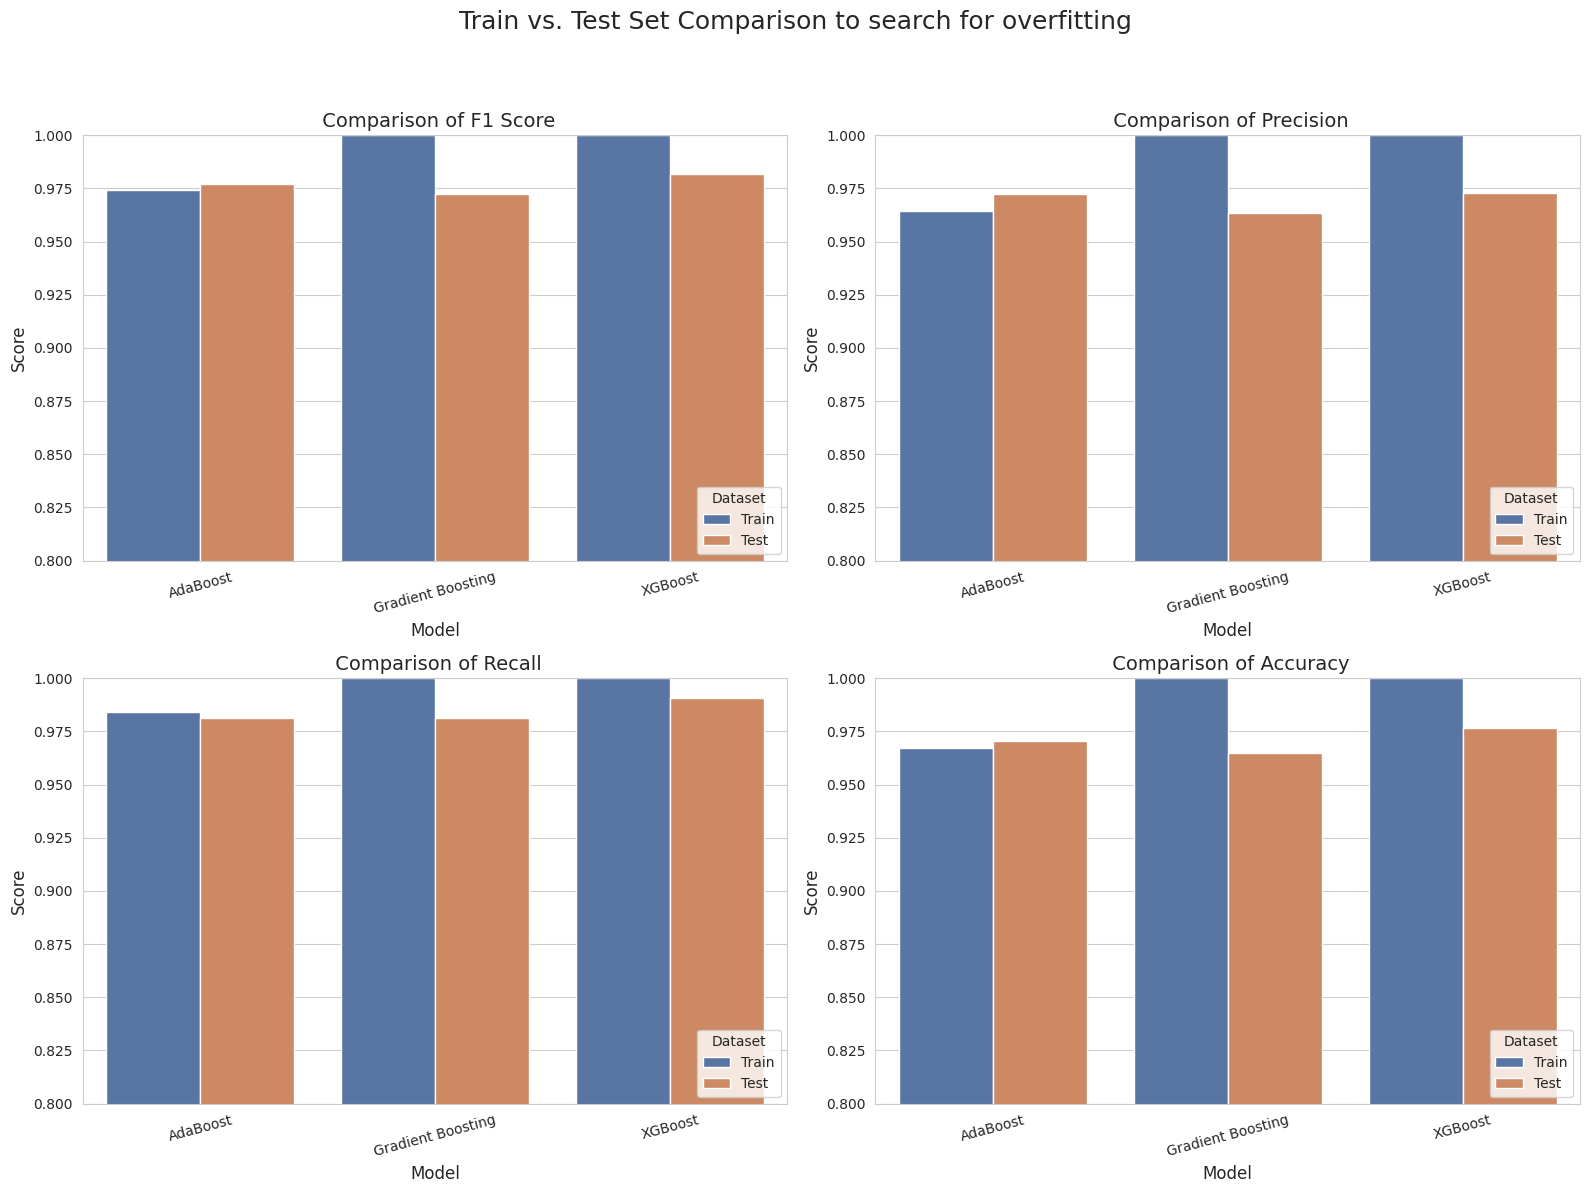

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

all_comparison_scores = []

def evaluate_model(model, X_data, y_data, set_name, model_name):
    y_pred = model.predict(X_data)
    all_comparison_scores.append({'Model': model_name, 'Set': set_name, 'Metric': 'F1 Score', 'Score': f1_score(y_data, y_pred)})
    all_comparison_scores.append({'Model': model_name, 'Set': set_name, 'Metric': 'Precision', 'Score': precision_score(y_data, y_pred)})
    all_comparison_scores.append({'Model': model_name, 'Set': set_name, 'Metric': 'Recall', 'Score': recall_score(y_data, y_pred)})
    all_comparison_scores.append({'Model': model_name, 'Set': set_name, 'Metric': 'Accuracy', 'Score': accuracy_score(y_data, y_pred)})


# Comparing AdaBoost on the train and test sets
if 'best_ada_model' in locals() and best_ada_model is not None:
    evaluate_model(best_ada_model, X_train, y_train, 'Train', 'AdaBoost')
    evaluate_model(best_ada_model, X_test, y_test, 'Test', 'AdaBoost')

# Comparing Gradient Boosting on the train and test sets
if 'best_gb_model' in locals() and best_gb_model is not None:
    evaluate_model(best_gb_model, X_train, y_train, 'Train', 'Gradient Boosting')
    evaluate_model(best_gb_model, X_test, y_test, 'Test', 'Gradient Boosting')


# Comparing XGBoost on the train and test sets
if 'best_xgb_model' in locals() and best_xgb_model is not None:
    evaluate_model(best_xgb_model, X_train, y_train, 'Train', 'XGBoost')
    evaluate_model(best_xgb_model, X_test, y_test, 'Test', 'XGBoost')



    comparison_df = pd.DataFrame(all_comparison_scores)

    metrics_to_plot = ['F1 Score', 'Precision', 'Recall', 'Accuracy']
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Train vs. Test Set Comparison to search for overfitting', fontsize=18, y=1.02)

    axes = axes.flatten()

    for i, metric in enumerate(metrics_to_plot):
        sns.barplot(x='Model', y='Score', hue='Set', data=comparison_df[comparison_df['Metric'] == metric], ax=axes[i], palette='deep')
        axes[i].set_title(f' Comparison of {metric}', fontsize=14)
        axes[i].set_xlabel('Model', fontsize=12)
        axes[i].set_ylabel('Score', fontsize=12)
        axes[i].set_ylim([0.8, 1.0])
        axes[i].tick_params(axis='x', rotation=15)
        axes[i].legend(title='Dataset', loc='lower right')

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()


# Unsupervised Learning Classifiers

In [26]:
# Requirements
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
import matplotlib.pyplot as plt
import seaborn as sns

# Wine dataset
wine = load_wine()
X = wine.data
y = wine.target

## Exploratory Data Analysis


In [27]:
X = pd.DataFrame(X, columns=wine.feature_names)
y = pd.Series(y, name='target')
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [28]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 178 entries, 0 to 177
Series name: target
Non-Null Count  Dtype
--------------  -----
178 non-null    int64
dtypes: int64(1)
memory usage: 1.5 KB


In [29]:
feature_names = X.columns
label_name = y.name

print("Feature names:", feature_names)
print("Label column:", label_name)

Feature names: Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')
Label column: target


This dataset contains 178 rows and 12 features. There are no missing values in the data.

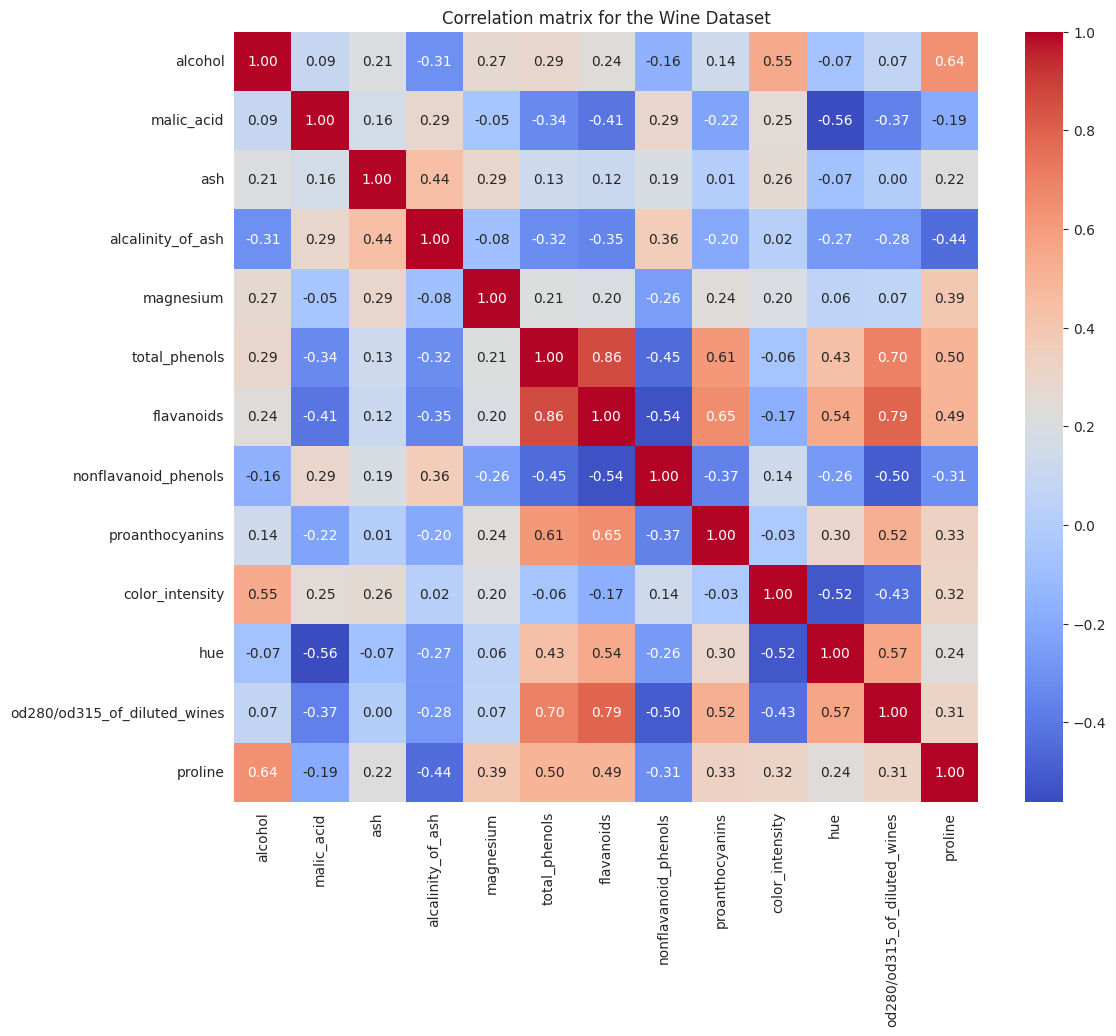

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
correlation_matrix_wine = X.corr()

# Visualization
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_wine, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation matrix for the Wine Dataset')
plt.show()

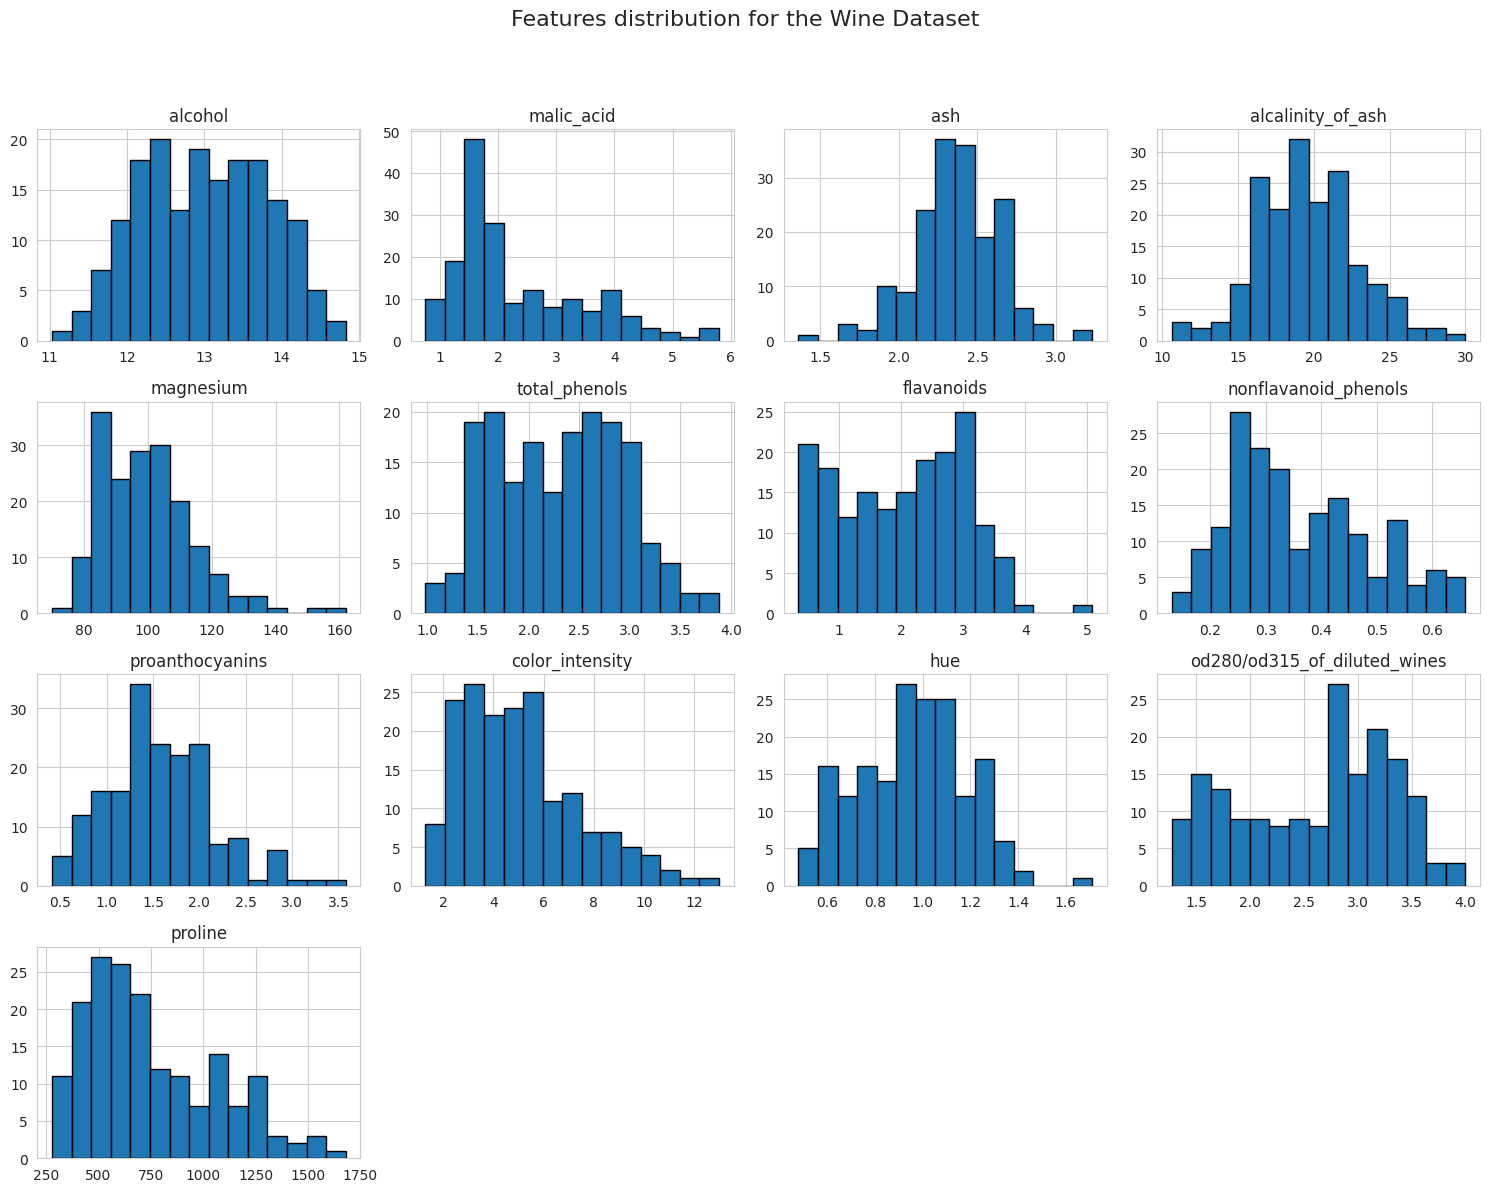

In [31]:

sns.set_style("whitegrid")

# Create histograms for all features in X
X.hist(figsize=(15, 12), bins=15, edgecolor='black')
plt.suptitle('Features distribution for the Wine Dataset', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

## Preprocessing

We will apply PCA for dimensionality reduction in order to prepare the data for clustering.

Number of features that explain 95% of the variance: 10
Initial number of features: 13
New number of features (95% variance): 10


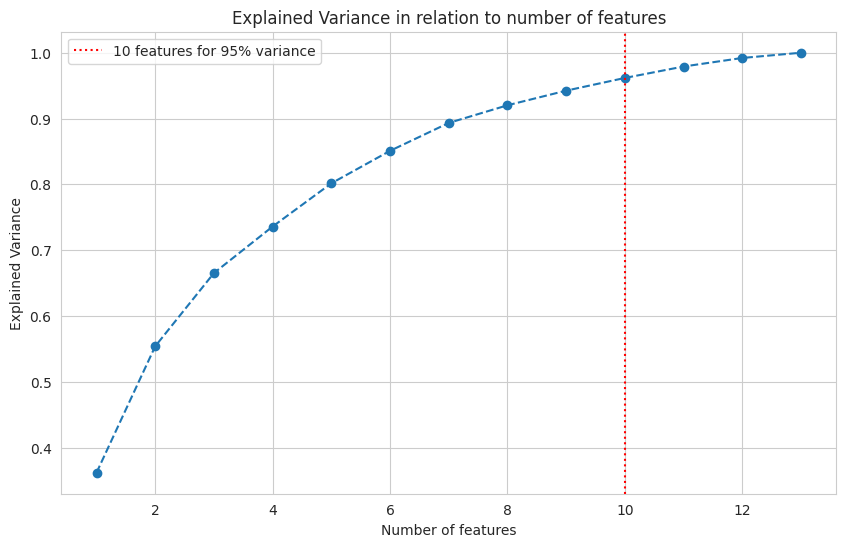

In [32]:
# Normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
cum_var_exp = np.cumsum(pca.explained_variance_ratio_)

# Features for 95% variance
num_components_95 = np.where(cum_var_exp >= 0.95)[0][0] + 1

print(f"Number of features that explain 95% of the variance: {num_components_95}")

# PCA with the new number of features
pca_final = PCA(n_components=num_components_95)
X_pca_final = pca_final.fit_transform(X_scaled)

print(f"Initial number of features: {X.shape[1]}")
print(f"New number of features (95% variance): {X_pca_final.shape[1]}")

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_var_exp) + 1), cum_var_exp, marker='o', linestyle='--')
plt.axvline(x=num_components_95, color='r', linestyle=':', label=f'{num_components_95} features for 95% variance')
plt.title('Explained Variance in relation to number of features')
plt.xlabel('Number of features')
plt.ylabel('Explained Variance')
plt.grid(True)
plt.legend()
plt.show()


## Inertia based K-means model



In [33]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca_final)
    inertia.append(kmeans.inertia_)

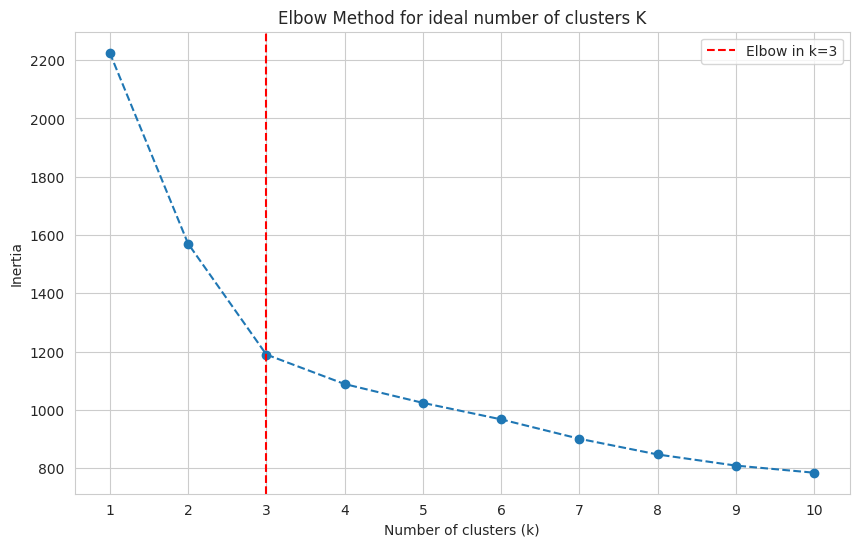

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.axvline(x=3, color='r', linestyle='--', label='Elbow in k=3')
plt.title('Elbow Method for ideal number of clusters K')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.legend()
plt.show()

By examining the plot, the ‘elbow’ point appears to be at k = 3. This indicates that after 3 clusters, the reduction in inertia becomes much smaller, suggesting that adding more clusters does not provide significant additional information about the structure of the data. Therefore, the appropriate number of clusters is 3.

In [35]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_values = [2, 3, 4] # Check k values around 3

print("Silhouette Scores for K-Means:")
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_pca_final)
    score = silhouette_score(X_pca_final, clusters)
    silhouette_scores.append(score)
    print(f"k={k}: {score:.4f}")

Silhouette Scores for K-Means:
k=2: 0.2793
k=3: 0.2987
k=4: 0.2733


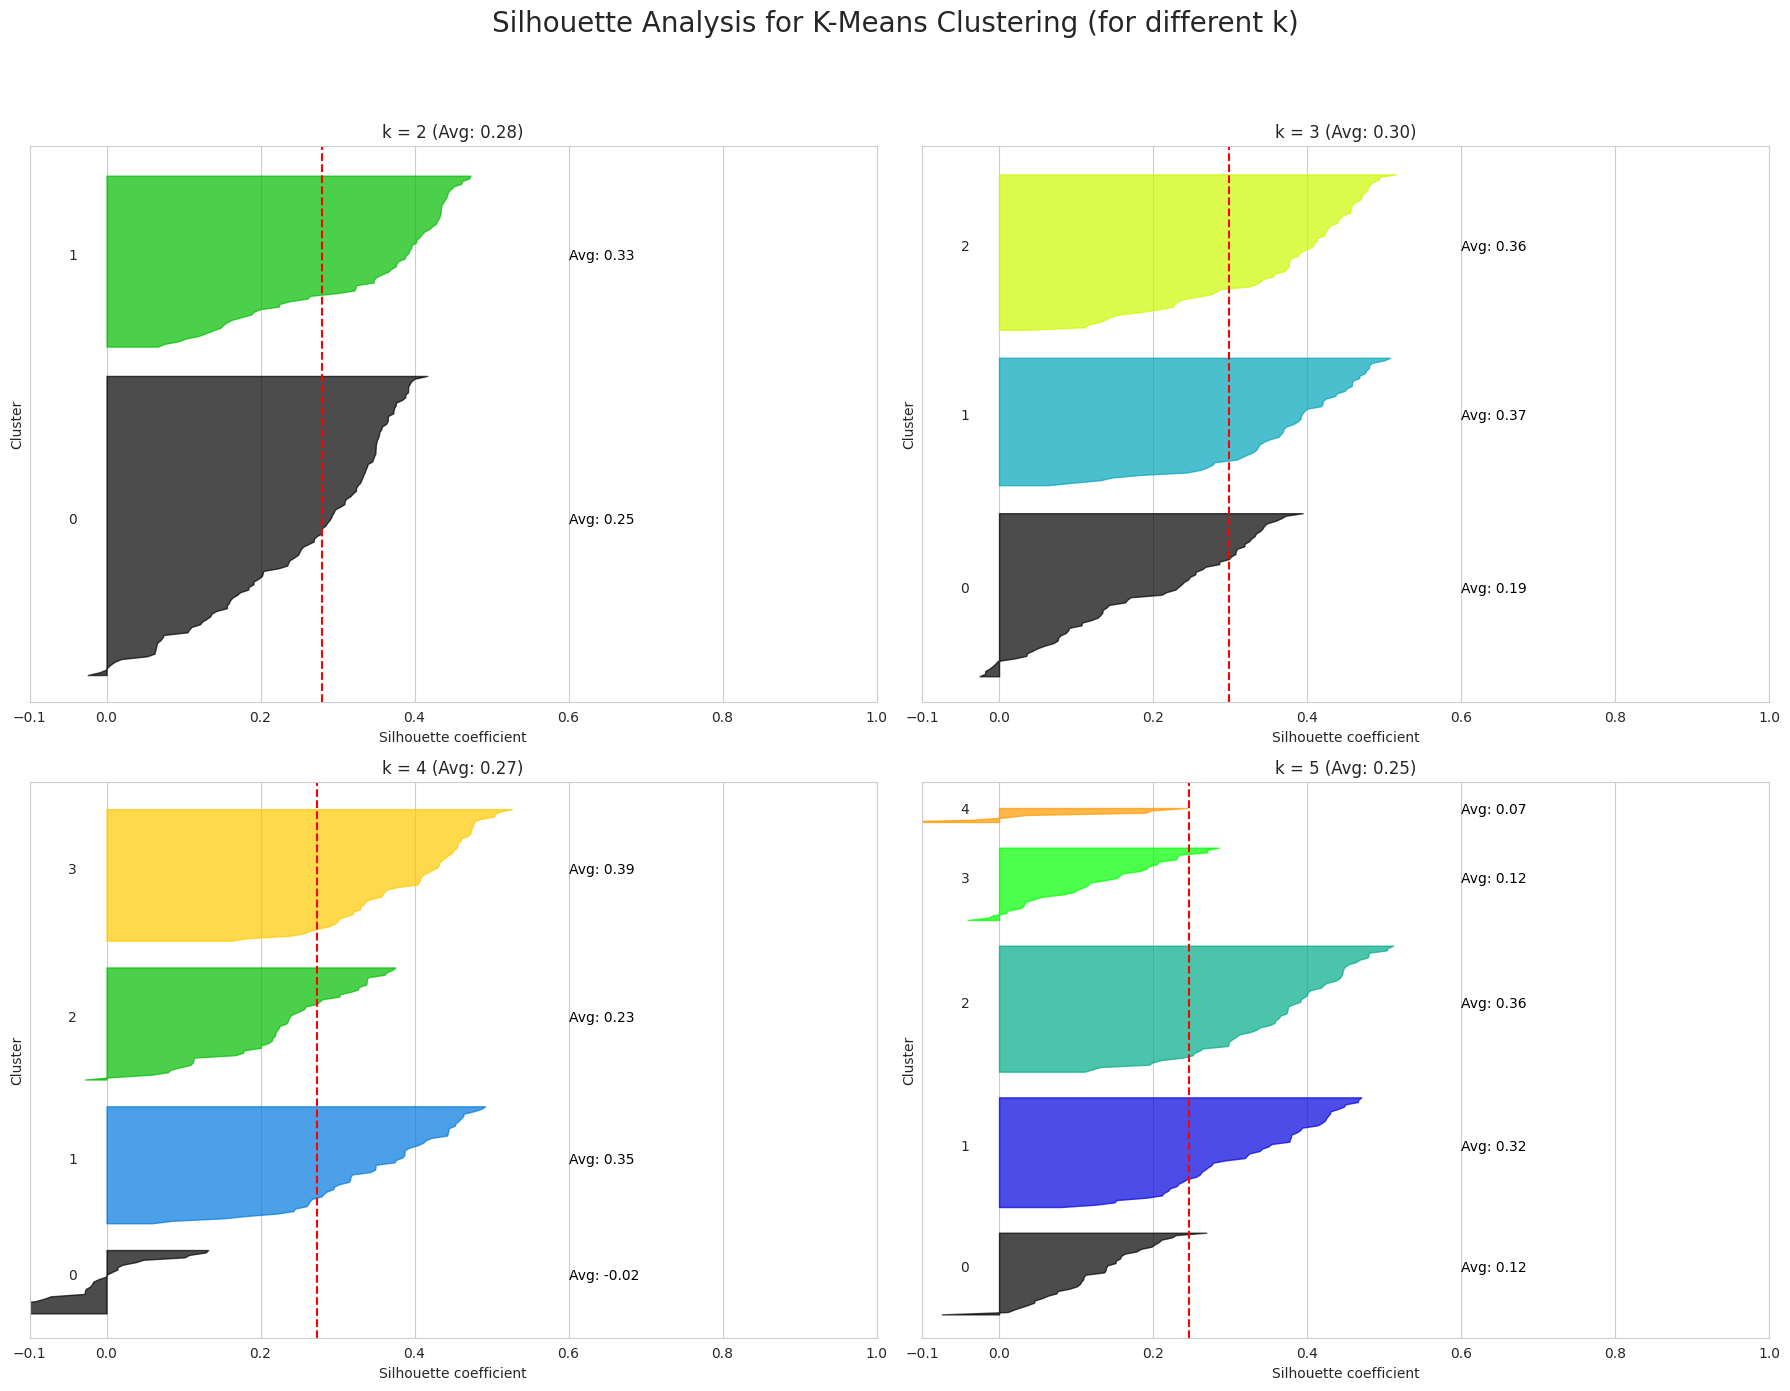

In [36]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
import numpy as np

def plot_silhouette_analysis(X, clusters, k, ax):
    silhouette_avg = silhouette_score(X, clusters)
    sample_silhouette_values = silhouette_samples(X, clusters)

    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(X) + (k + 1) * 10])

    y_lower = 10
    for i in range(k):
        ith_cluster_silhouette_values = \
            sample_silhouette_values[clusters == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                          0,
                          ith_cluster_silhouette_values,
                          facecolor=color,
                          edgecolor=color,
                          alpha=0.7)

        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        cluster_avg_silhouette = ith_cluster_silhouette_values.mean()
        ax.text(0.6, y_lower + 0.5 * size_cluster_i, f'Avg: {cluster_avg_silhouette:.2f}', color='black', fontsize=10)

        y_lower = y_upper + 10

    ax.set_title(f"k = {k} (Avg: {silhouette_avg:.2f})")
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Cluster")
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_yticks([])
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])


fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Silhouette Analysis for K-Means Clustering (for different k)', fontsize=20, y=1.02)

# k=2
k = 2
kmeans_k2 = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters_k2 = kmeans_k2.fit_predict(X_pca_final)
plot_silhouette_analysis(X_pca_final, clusters_k2, k, axes[0, 0])

# k=3 (the chosen one it was supposed to bring balance to the force)
k = 3
kmeans_k3 = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters_k3 = kmeans_k3.fit_predict(X_pca_final)
plot_silhouette_analysis(X_pca_final, clusters_k3, k, axes[0, 1])

# k=4
k = 4
kmeans_k4 = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters_k4 = kmeans_k4.fit_predict(X_pca_final)
plot_silhouette_analysis(X_pca_final, clusters_k4, k, axes[1, 0])

# k=5
k = 5
kmeans_k5 = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters_k5 = kmeans_k5.fit_predict(X_pca_final)
plot_silhouette_analysis(X_pca_final, clusters_k5, k, axes[1, 1])

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

In [37]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_kmeans = kmeans_final.fit_predict(X_pca_final)

print("K-Means clustering with k=3.")
print(f"Number of samples for clustering: {clusters_kmeans.shape}")

K-Means clustering with k=3.
Number of samples for clustering: (178,)


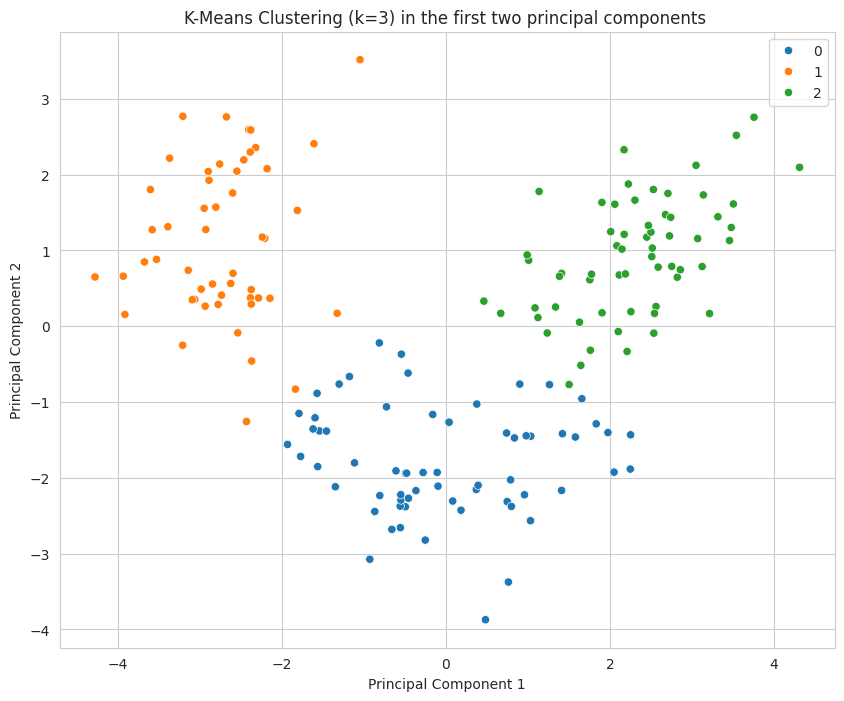

In [38]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca_final[:, 0], y=X_pca_final[:, 1], hue=clusters_kmeans, palette='tab10', legend='full')
plt.title('K-Means Clustering (k=3) in the first two principal components ')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

### 5. Hierarchical Agglomerative Clustering (HAC)


In [39]:
from sklearn.cluster import AgglomerativeClustering

hac = AgglomerativeClustering(n_clusters=3)
clusters_hac = hac.fit_predict(X_pca_final)

print("Hierarchical Agglomerative Clustering with k=3.")
print(f"Number of samples: {clusters_hac.shape}")

Hierarchical Agglomerative Clustering with k=3.
Number of samples: (178,)


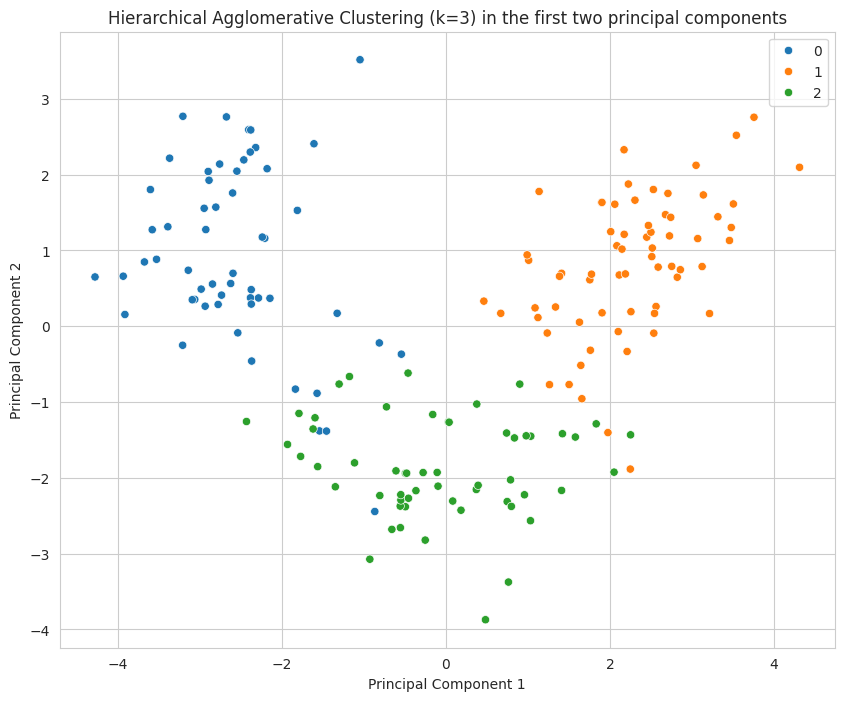

In [40]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca_final[:, 0], y=X_pca_final[:, 1], hue=clusters_hac, palette='tab10', legend='full')
plt.title('Hierarchical Agglomerative Clustering (k=3) in the first two principal components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

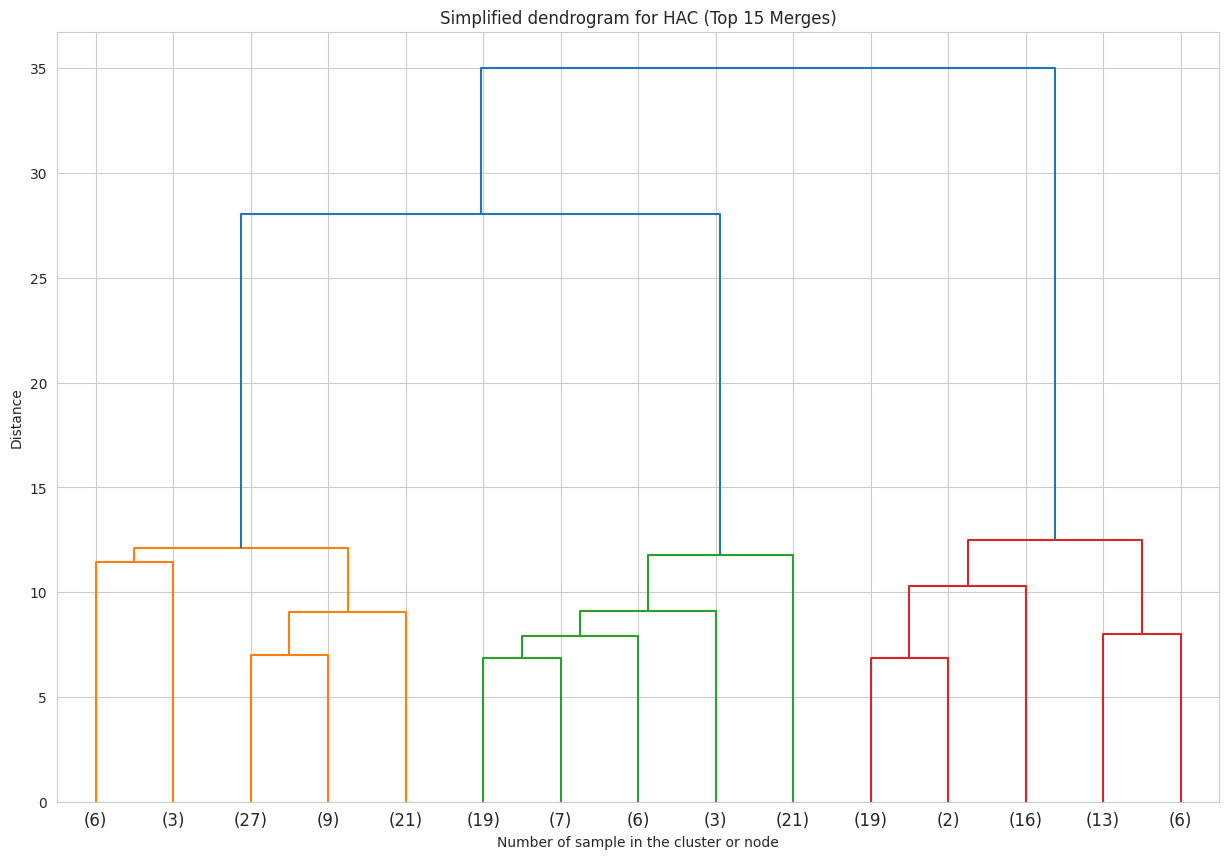

In [41]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_pca_final, method='ward')

plt.figure(figsize=(15, 10))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           truncate_mode='lastp',
           p=15)
plt.title('Simplified dendrogram for HAC (Top 15 Merges)')
plt.xlabel('Number of sample in the cluster or node')
plt.ylabel('Distance')
plt.show()

From the plots, we observe that HAC leaves several points positioned extremely far from their corresponding clusters and even inside other clusters. In contrast, standard K‑Means performs much better at establishing clear boundaries between clusters. Based on the same visualizations, choosing 3 clusters appears reasonable, as the points naturally form three compact regions. The superiority of K‑Means is also evident when comparing their performance.

## Evaluation

In [42]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Αξιολόγηση
print("Evaluation K-Means:")
print(f"Adjusted Rand Index: {adjusted_rand_score(y, clusters_kmeans):.4f}")
print(f"Normalized Mutual Information: {normalized_mutual_info_score(y, clusters_kmeans):.4f}")

print("\nEvaluation HAC:")
print(f"Adjusted Rand Index: {adjusted_rand_score(y, clusters_hac):.4f}")
print(f"Normalized Mutual Information: {normalized_mutual_info_score(y, clusters_hac):.4f}")

Evaluation K-Means:
Adjusted Rand Index: 0.8975
Normalized Mutual Information: 0.8759

Evaluation HAC:
Adjusted Rand Index: 0.7587
Normalized Mutual Information: 0.7624


We also observe from the Rand Index and NMI evaluation metrics that K‑Means performs better when compared to the true labels contained in y.